In [150]:
from braket.circuits import Circuit
import numpy as np
from braket.devices import LocalSimulator
import matplotlib.pyplot as plt
from braket.aws import AwsDevice
import random
accuracyList =[]

In [186]:
# set up the on-demand simulator SV1
device = AwsDevice("arn:aws:braket:us-west-1::device/qpu/rigetti/Aspen-M-3")

In [152]:
device = LocalSimulator()

In [54]:
edge_label= [[ [ 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 11, 11, 12, 12, 12, 13, 13, 14, 14, 14, 15, 16 ], [ 1, 5, 0, 2, 1, 3, 2, 4, 9, 3, 5, 6, 0, 4, 4, 7, 6, 8, 7, 9, 13, 3, 8, 10, 9, 11, 10, 12, 11, 13, 14, 8, 12, 12, 15, 16, 14, 14 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12 ], [ 1, 9, 0, 2, 1, 3, 7, 2, 4, 3, 5, 4, 6, 5, 7, 2, 6, 8, 7, 9, 10, 0, 8, 8, 11, 12, 10, 10 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12 ], [ 1, 9, 0, 2, 1, 3, 7, 2, 4, 8, 3, 5, 4, 6, 5, 7, 2, 6, 3, 9, 10, 0, 8, 8, 11, 12, 10, 10 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 18 ], [ 1, 5, 0, 2, 1, 3, 2, 4, 12, 3, 5, 6, 0, 4, 4, 7, 11, 6, 8, 7, 9, 8, 10, 9, 11, 15, 6, 10, 12, 3, 11, 13, 12, 14, 16, 13, 15, 10, 14, 13, 17, 18, 16, 16 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 5, 6, 7, 7, 7, 8, 9, 10 ], [ 1, 5, 0, 2, 1, 3, 10, 2, 4, 7, 3, 5, 0, 4, 6, 5, 3, 8, 9, 7, 7, 2 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 18, 19, 19, 19, 20, 21, 22, 22, 22, 23, 24, 25, 25, 25, 26, 27 ], [ 1, 9, 0, 2, 1, 3, 7, 2, 4, 25, 3, 5, 4, 6, 22, 5, 7, 15, 2, 6, 8, 7, 9, 13, 0, 8, 10, 9, 11, 19, 10, 12, 11, 13, 16, 8, 12, 14, 13, 15, 6, 14, 12, 17, 18, 16, 16, 10, 20, 21, 19, 19, 5, 23, 24, 22, 22, 3, 26, 27, 25, 25 ] ],
              [ [ 0, 1, 1, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 7, 8, 9, 10, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15 ], [ 1, 0, 2, 6, 1, 3, 2, 4, 10, 3, 5, 4, 6, 1, 5, 7, 6, 8, 9, 7, 7, 3, 11, 15, 10, 12, 11, 13, 12, 14, 13, 15, 10, 14 ] ],
              [ [ 0, 1, 1, 1, 2, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 14, 14, 15, 15, 15, 16, 16, 17, 17, 17, 18, 19 ], [ 1, 0, 2, 3, 1, 1, 4, 3, 5, 9, 4, 6, 5, 7, 6, 8, 12, 7, 9, 10, 4, 8, 8, 11, 10, 12, 16, 7, 11, 13, 12, 14, 13, 15, 14, 16, 17, 11, 15, 15, 18, 19, 17, 17 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 10, 11 ], [ 1, 8, 0, 2, 1, 3, 6, 2, 4, 3, 5, 4, 6, 2, 5, 7, 6, 8, 0, 7, 9, 8, 10, 11, 9, 9 ] ],
              [ [ 0, 1, 1, 1, 2, 2, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 11, 11, 12, 12, 12, 13, 13, 14, 14, 14, 15, 16 ], [ 1, 0, 2, 6, 1, 3, 2, 4, 3, 5, 9, 4, 6, 7, 1, 5, 5, 8, 7, 9, 13, 4, 8, 10, 9, 11, 10, 12, 11, 13, 14, 8, 12, 12, 15, 16, 14, 14 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 14, 15, 16 ], [ 1, 5, 0, 2, 1, 3, 2, 4, 9, 3, 5, 6, 0, 4, 4, 7, 6, 8, 14, 7, 9, 13, 3, 8, 10, 9, 11, 10, 12, 11, 13, 8, 12, 7, 15, 16, 14, 14 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 15, 15, 16, 17, 17, 17, 18, 19 ], [ 1, 9, 0, 2, 1, 3, 7, 2, 4, 3, 5, 4, 6, 17, 5, 7, 15, 2, 6, 8, 7, 9, 13, 0, 8, 10, 9, 11, 10, 12, 11, 13, 16, 8, 12, 14, 13, 15, 6, 14, 12, 5, 18, 19, 17, 17 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 14, 14, 14, 15, 15, 16, 16, 16, 17, 18, 19, 19, 19, 20, 21 ], [ 1, 5, 0, 2, 1, 3, 2, 4, 12, 3, 5, 6, 0, 4, 4, 7, 11, 6, 8, 7, 9, 8, 10, 19, 9, 11, 15, 6, 10, 12, 3, 11, 13, 12, 14, 13, 15, 16, 10, 14, 14, 17, 18, 16, 16, 9, 20, 21, 19, 19 ] ],
              [ [ 0, 1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7, 8, 8, 9, 9, 10, 10, 10, 11, 12 ], [ 1, 0, 2, 9, 1, 3, 7, 2, 4, 3, 5, 10, 4, 6, 5, 7, 2, 6, 8, 7, 9, 1, 8, 4, 11, 12, 10, 10 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 18 ], [ 1, 13, 0, 2, 1, 3, 11, 2, 4, 3, 5, 4, 6, 10, 5, 7, 6, 8, 7, 9, 16, 8, 10, 15, 5, 9, 11, 2, 10, 12, 11, 13, 14, 0, 12, 12, 15, 9, 14, 8, 17, 18, 16, 16 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 14, 14, 15, 15, 15, 16, 16, 16, 17, 18, 19, 19, 19, 20, 21 ], [ 1, 5, 0, 2, 1, 3, 2, 4, 12, 3, 5, 6, 0, 4, 4, 7, 11, 6, 8, 7, 9, 8, 10, 19, 9, 11, 15, 6, 10, 12, 3, 11, 13, 12, 14, 13, 15, 10, 14, 16, 15, 17, 18, 16, 16, 9, 20, 21, 19, 19 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 7, 7, 7, 8, 9, 10 ], [ 1, 5, 0, 2, 1, 3, 10, 2, 4, 7, 3, 5, 6, 0, 4, 4, 3, 8, 9, 7, 7, 2 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 6, 7, 7, 8, 8, 8, 9, 9, 10, 10, 11, 11, 11, 12, 12, 12, 13, 14, 14, 14, 15, 16 ], [ 1, 5, 0, 2, 1, 3, 2, 4, 12, 3, 5, 6, 0, 4, 4, 7, 11, 6, 8, 7, 9, 14, 8, 10, 9, 11, 6, 10, 12, 3, 11, 13, 12, 8, 15, 16, 14, 14 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7, 8, 8, 9, 9, 10, 10, 10, 11, 12 ], [ 1, 9, 0, 2, 1, 3, 7, 2, 4, 3, 5, 10, 4, 6, 5, 7, 2, 6, 8, 7, 9, 0, 8, 4, 11, 12, 10, 10 ] ],
              [ [ 0, 0, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 7, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 12, 12, 13, 13, 13, 14, 14, 15, 15, 15, 16, 17 ], [ 1, 5, 0, 2, 1, 3, 10, 2, 4, 8, 3, 5, 0, 4, 6, 5, 7, 6, 3, 9, 8, 10, 14, 2, 9, 11, 10, 12, 11, 13, 12, 14, 15, 9, 13, 13, 16, 17, 15, 15 ] ]

             ]

In [55]:
node_attr= [[ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 0, 0, 1, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 0, 1, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ],
             [ [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 1, 0, 0, 0, 0, 0, 0 ], [ 0, 1, 0, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ], [ 0, 0, 1, 0, 0, 0, 0 ] ]
]

In [56]:
def adj_graph(edge_index):
    
# Example edge_index
  #  edge_index = np.array([[0, 1, 2],
          #             [1, 2, 3]])

# Determine the number of nodes in the graph
    num_nodes = np.max(edge_index) + 1
    list1 = []

# Initialize an empty dictionary to store the neighbor sets
    neighbor_sets = {node: set() for node in range(num_nodes)}

# Iterate over each edge and add neighbors to the sets
    for source, target in edge_index.T:
        
        neighbor_sets[source].add(target)
        neighbor_sets[target].add(source)  # If the graph is undirected

# Print the neighbor sets
    list1 = [[x]+list(y) for x, y in neighbor_sets.items()]
    return list1

    

In [157]:
def quantumclassifier(x,p,device,crt):
    crt = Circuit()
    for i in range(len(x)):
        crt.h(i)
    k=0
    for i in x:
        #crt.rx(k,p)
        crt.ry(k,p)
        #crt.rz(k,p)
        #for j in range(len(i)):
       # val = random.uniform(np.pi/2,np.pi)
           # theta = p#* i[j]
           # unitary_matrix = np.array([[np.cos(theta), -np.sin(theta)],
            #             [np.sin(theta), np.cos(theta)]])
            #crt.unitary(matrix = unitary_matrix,targets=[k])
            #crt.rx(k,theta)
            #crt.ry(k,theta)
            #crt.rz(k,theta)
        
        
        k +=1    
    i = 0
    j = 1

    while i<=len(x)-1:
    
        if i==j:
        
            i+=1
        if j<=len(x)-1:
        
            crt.cnot(j,i)
            i+=1
            j+=1
        
        else:
            j =0
 
        
    for i in range(len(x)):
        crt.cnot(i,len(x))
   # crt.unitary(matrix = mat, targets =[len(x)] ) 
    crt.ry(len(x),np.pi*p)
    #crt.z(len(x))
    c = crt.probability(target=[len(x)])
    #print(crt)
    #for i in range(2):
    result = device.run(crt, shots=1000).result()
    state = result.values[0]
    label = 0
    if state[0]>state[1]:
        label = 0
    else:
        label = 1
    #print(crt)    
    return label

In [147]:
def MC(x,p,crt):
    #crt = Circuit()
    for i in range(len(x)):
        theta = p[i]*x[i]
        unitary_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                           [np.sin(theta), np.cos(theta)]])
       # unitary_gate = UnitaryGate(unitary_matrix)
        crt.unitary(matrix = unitary_matrix,targets = [0])
    #result = device.run(crt, shots=1000).result()
    unitary = crt.as_unitary() 
    #zprint(crt)
    return unitary

In [165]:
def datamapper(x,crt):
    p1 = []
    Loss = []
    Lmin = []
    for i in range(10):
        for i in range(7):
            p1 .append(random.uniform(0,np.pi/2))                                              
        uni = []
        j = 1
        for i in range(len(x)):
            unitary = (MC(x[i],p1,crt))
            unitary = unitary.flatten()
            uni.append(unitary)                      
        #Lmin = []
        for i in range(len(x)):
            L = 0 
            for j in range(len(x)):
                if i !=j:
                    D = np.arccos(np.inner(uni[i],uni[j]))
                    d = np.dot(x[i],x[j])
                    L +=np.abs(D-d)
                    
            Lmin.append(L)
            Loss.append(min(Lmin))
    return min(Loss)       
    

In [208]:
labelList = []
y = [1,0,0,1,0,1,0,1,0,1,1,1,1,0,1,1,0,1,0,1]

In [209]:
#crt = Circuit()
for x in range(20):
    crt = Circuit()
    a= np.array(edge_label[x])
    se = adj_graph(a)
    feature = []
    label1 = []
    p = datamapper(node_attr[x],crt)
   # print(p)
    for k in range(len(se)):
       # crt = Circuit()
        j =0
        for i in se[k]:
            feature.append(node_attr[x][j])
            j+=1
            #print(feature)
      #  p = datamapper(feature,crt)
        #print(p)
        label = quantumclassifier(feature,p,device,crt)
        #print(label)
        feature = []
        label1.append(label)
    print(label1)    
    count0 = label1.count(0)
    count1 = label1.count(1)
    if count0 > count1:
            labelList.append(0)
    else:
            labelList.append(1)
    label1 = []    
    
        

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0]
[1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
[1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]
[1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 0, 0, 0, 0, 0,

In [210]:
labelList

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]

In [211]:
y

[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1]

In [212]:
count = 0
#accuracyList =[]
for i in range(len(labelList)):
    if y[i] == labelList[i]:
        count+=1
accuracy = count*100/len(y)
#accuracyList.append(accuracy)
accuracy

55.0

In [213]:
confusion_matrix

NameError: name 'confusion_matrix' is not defined

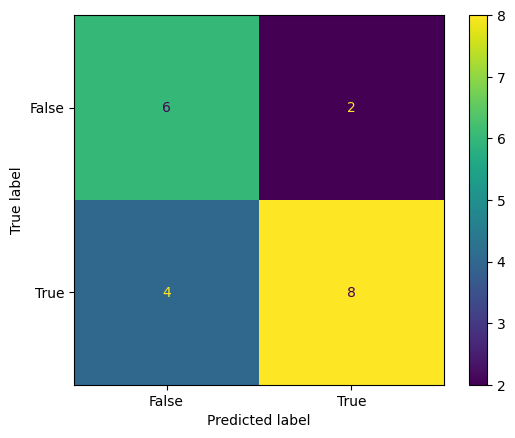

In [371]:
confusion_matrix = metrics.confusion_matrix(y, labelList)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

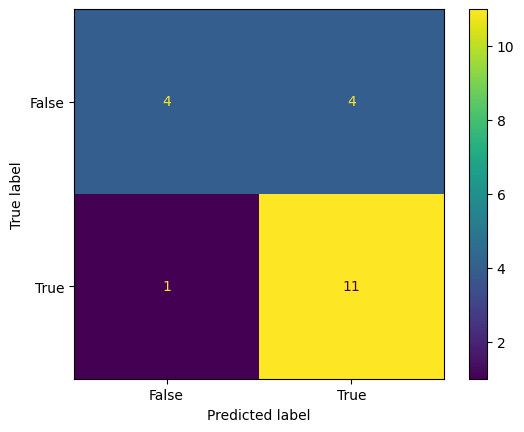

In [386]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

#actual = numpy.random.binomial(1,.9,size = 1000)
#predicted = numpy.random.binomial(1,.9,size = 1000)

confusion_matrix = metrics.confusion_matrix(y, labelList)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

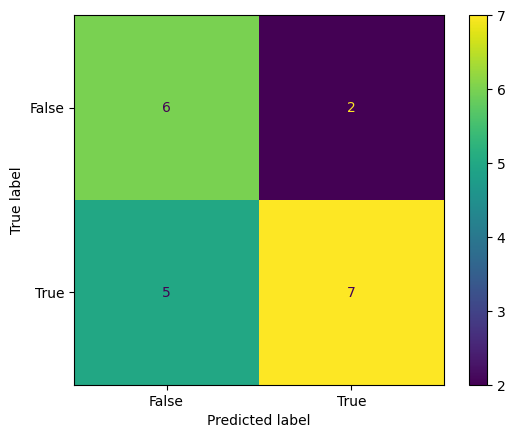

In [356]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

#actual = numpy.random.binomial(1,.9,size = 1000)
#predicted = numpy.random.binomial(1,.9,size = 1000)

confusion_matrix = metrics.confusion_matrix(y, labelList)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [192]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [203]:
precision = precision_score(y, labelList)
recall = recall_score(y,labelList)

In [204]:
precision

0.5714285714285714

In [205]:
recall

0.6666666666666666

In [206]:
F1 = (2*precision*recall)/(precision+recall)

In [207]:
F1

0.6153846153846153

In [125]:
from braket.circuits import Circuit
crt = Circuit()

In [126]:
crt.cnot(0,1)

Circuit('instructions': [Instruction('operator': CNot('qubit_count': 2), 'target': QubitSet([Qubit(0), Qubit(1)]), 'control': QubitSet([]), 'control_state': (), 'power': 1)])

In [127]:
print(crt)

T  : |0|
        
q0 : -C-
      | 
q1 : -X-

T  : |0|


In [19]:
result = device.run(crt, shots=1).result()

In [36]:
uni = crt.as_unitary()

In [78]:
p = []
for i in range(len(uni)):
    p1 =(np.matmul((uni[i].reshape(len(uni[0]),1)),(uni[i].reshape(1,len(uni[0])))))
    p.append(p1)

In [79]:
p

[array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]]),
 array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]]),
 array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]]),
 array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])]

In [80]:
h = p[len(p)-1]
for i in range(len(p)-1):
    h += p[i]
    print(h)

[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]


In [ ]:
a = p[

In [82]:
for i in range(4):    
    a += p[i]+p[j]
a

array([[3.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 6.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 3.+0.j]])

In [83]:
en = a.trace()

In [84]:
en

(13+0j)

In [90]:
state0= [[1,0],[0,0]]
state1 = [[0,0],[0,1]]

In [131]:
crt.state_vector()

Circuit('instructions': [Instruction('operator': CNot('qubit_count': 2), 'target': QubitSet([Qubit(0), Qubit(1)]), 'control': QubitSet([]), 'control_state': (), 'power': 1)], 'result_types': [StateVector()])

In [135]:
s =crt.as_unitary()

In [136]:
r = abs(s[0])**2

In [139]:
a =np.array(edge_label[0])
adj_graph(a)

[[0, 1, 5],
 [1, 0, 2],
 [2, 1, 3],
 [3, 9, 2, 4],
 [4, 3, 5, 6],
 [5, 0, 4],
 [6, 4, 7],
 [7, 8, 6],
 [8, 9, 13, 7],
 [9, 8, 10, 3],
 [10, 9, 11],
 [11, 10, 12],
 [12, 11, 13, 14],
 [13, 8, 12],
 [14, 16, 12, 15],
 [15, 14],
 [16, 14]]

In [143]:
def neumann(phi):
    print(phi)
    print(len(phi))